In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [2]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Dell\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [3]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Dell\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [2]:
df = pd.read_csv('twitter_disaster (1).csv')
df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 297.5 KB


In [4]:
df.describe

<bound method NDFrame.describe of          id keyword location  \
0         1     NaN      NaN   
1         4     NaN      NaN   
2         5     NaN      NaN   
3         6     NaN      NaN   
4         7     NaN      NaN   
...     ...     ...      ...   
7608  10869     NaN      NaN   
7609  10870     NaN      NaN   
7610  10871     NaN      NaN   
7611  10872     NaN      NaN   
7612  10873     NaN      NaN   

                                                   text  target  
0     Our Deeds are the Reason of this #earthquake M...       1  
1                Forest fire near La Ronge Sask. Canada       1  
2     All residents asked to 'shelter in place' are ...       1  
3     13,000 people receive #wildfires evacuation or...       1  
4     Just got sent this photo from Ruby #Alaska as ...       1  
...                                                 ...     ...  
7608  Two giant cranes holding a bridge collapse int...       1  
7609  @aria_ahrary @TheTawniest The out of control w.

In [5]:
df.isnull().sum()

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

INSIGHT:
- keyword and location contain missing values.


In [6]:
df['keyword'] = df['keyword'].fillna('Unknown')

In [7]:
df['location'] = df['location'].fillna('Unknown')

In [8]:
df.isnull().sum()

id          0
keyword     0
location    0
text        0
target      0
dtype: int64

In [9]:
print(df.shape)

(7613, 5)


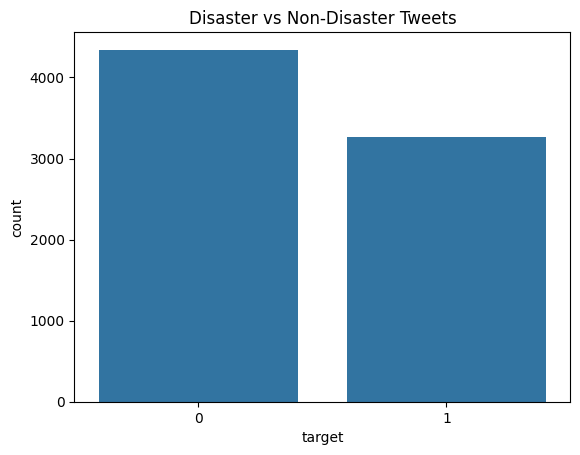

In [10]:
sns.countplot(x='target', data=df)
plt.title('Disaster vs Non-Disaster Tweets')
plt.show()

Insight:
- Dataset is slightly imbalanced.
- More tweets are non-disaster compared to disaster tweets.
- This imbalance should be considered while evaluating models.

In [11]:
df['target'].value_counts(normalize=True)*100

target
0    57.034021
1    42.965979
Name: proportion, dtype: float64

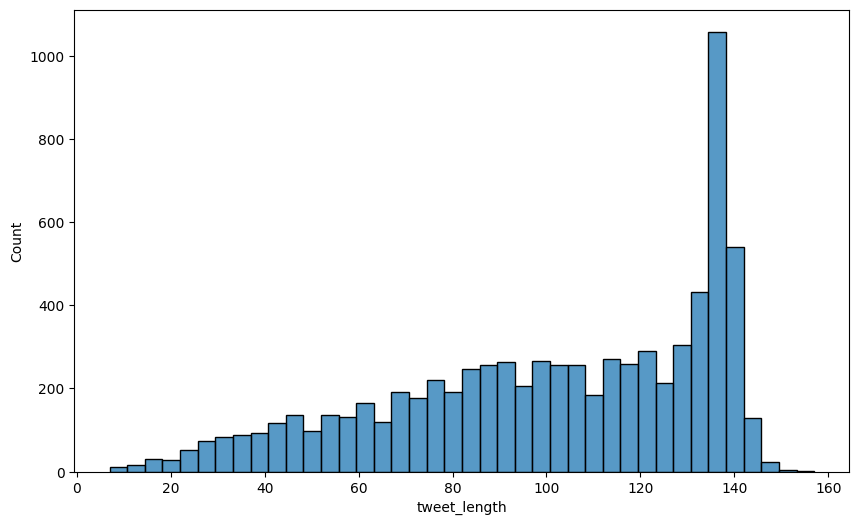

In [12]:
df['tweet_length'] = df['text'].apply(len)

plt.figure(figsize=(10,6))
sns.histplot(df['tweet_length'], bins=40)
plt.show()

INSIGHT:
• Most tweet lengths lie between 120 and 140 characters.
• The distribution is negatively skewed.
• Very short tweets are uncommon.
• Users prefer posting detailed tweets close to the character limit.

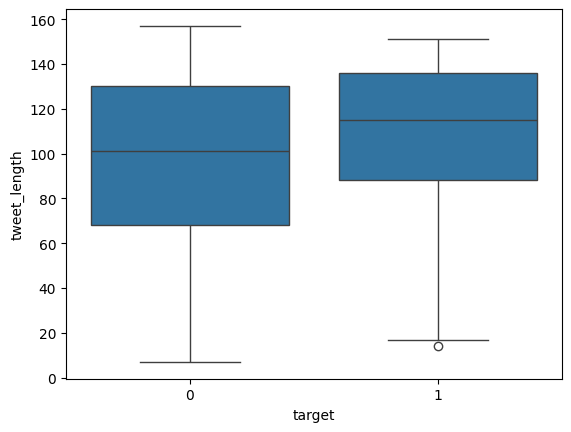

In [13]:
sns.boxplot(x='target', y='tweet_length', data=df)
plt.show()

INSIGHT:
Tweets belonging to target= 1 tend to be slightly longer than those in target =0, although the distributions overlap considerably.

In [14]:
df['keyword'].value_counts().head(10)

keyword
Unknown        61
fatalities     45
armageddon     42
deluge         42
body%20bags    41
damage         41
harm           41
sinking        41
collided       40
evacuate       40
Name: count, dtype: int64

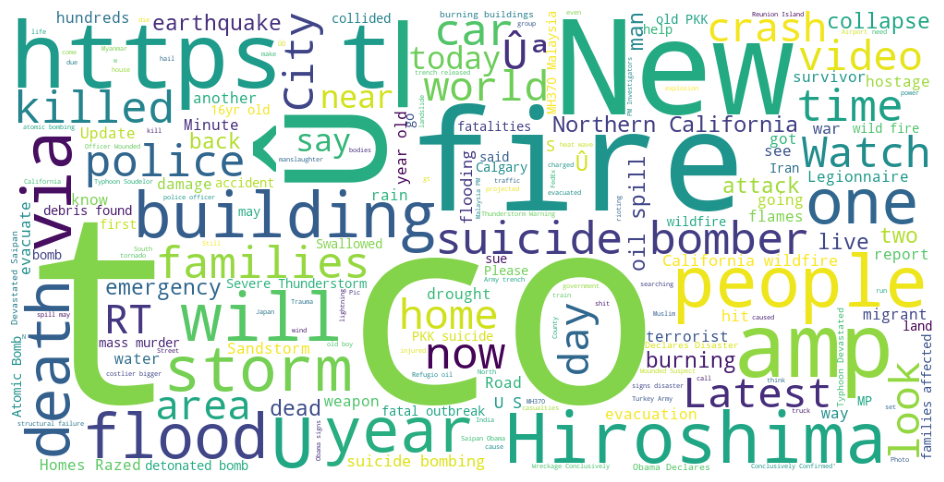

In [15]:
disaster = ' '.join(df[df['target']==1]['text'])

wc = WordCloud(
    background_color='white',
    width=1000,
    height=500
).generate(disaster)

plt.figure(figsize=(15,6))
plt.imshow(wc)
plt.axis('off')
plt.show()

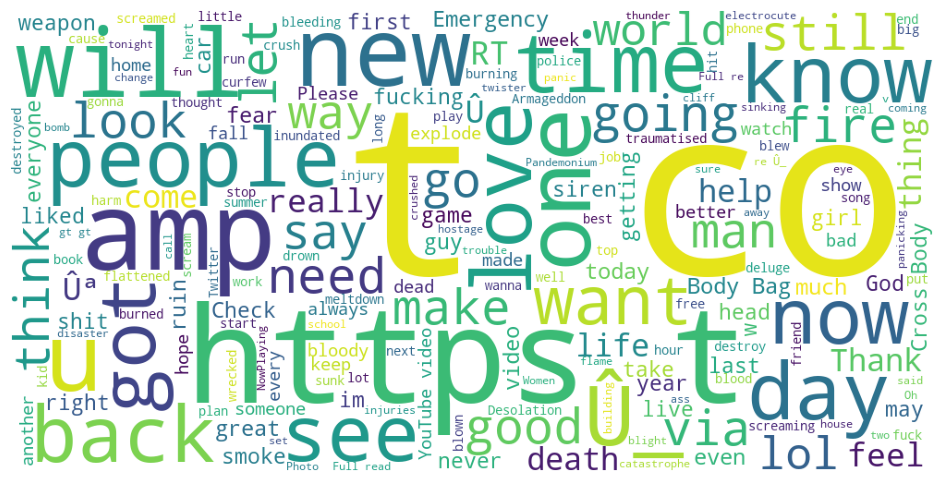

In [16]:
non_disaster = ' '.join(df[df['target']==0]['text'])

wc = WordCloud(
    background_color='white',
    width=1000,
    height=500
).generate(non_disaster)

plt.figure(figsize=(15,6))
plt.imshow(wc)
plt.axis('off')
plt.show()

In [17]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    return text

df['clean_text'] = df['text'].apply(clean_text)

Insight:

-Cleaning removes:

1. URLs
2. Mentions
3. Punctuation
4. Special characters

This improves model performance.

In [18]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=10000
)

X = tfidf.fit_transform(df['clean_text'])

y = df['target']

Insight:

TF-IDF converts text into numerical values based on word importance.

In [19]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

LOGISTIC REGRESSION

In [20]:
lr = LogisticRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

print(classification_report(y_test,pred_lr))

              precision    recall  f1-score   support

           0       0.79      0.92      0.85       869
           1       0.87      0.68      0.76       654

    accuracy                           0.82      1523
   macro avg       0.83      0.80      0.81      1523
weighted avg       0.83      0.82      0.82      1523



NAIVE BAYES

In [21]:
nb = MultinomialNB()

nb.fit(X_train,y_train)

pred_nb = nb.predict(X_test)

print(classification_report(y_test,pred_nb))

              precision    recall  f1-score   support

           0       0.80      0.90      0.85       869
           1       0.84      0.70      0.76       654

    accuracy                           0.81      1523
   macro avg       0.82      0.80      0.81      1523
weighted avg       0.82      0.81      0.81      1523



SVM

In [22]:
svm = LinearSVC()

svm.fit(X_train,y_train)

pred_svm = svm.predict(X_test)

print(classification_report(y_test,pred_svm))

              precision    recall  f1-score   support

           0       0.79      0.85      0.82       869
           1       0.78      0.70      0.74       654

    accuracy                           0.79      1523
   macro avg       0.79      0.78      0.78      1523
weighted avg       0.79      0.79      0.79      1523



RANDOM FOREST

In [23]:
rf = RandomForestClassifier()

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

print(classification_report(y_test,pred_rf))

              precision    recall  f1-score   support

           0       0.78      0.86      0.82       869
           1       0.79      0.68      0.73       654

    accuracy                           0.78      1523
   macro avg       0.79      0.77      0.78      1523
weighted avg       0.79      0.78      0.78      1523



In [24]:
models = {
    'Logistic Regression':
        accuracy_score(y_test,pred_lr),

    'Naive Bayes':
        accuracy_score(y_test,pred_nb),

    'SVM':
        accuracy_score(y_test,pred_svm),

    'Random Forest':
        accuracy_score(y_test,pred_rf)
}

pd.DataFrame(models.items(),
             columns=['Model','Accuracy'])

,Model,Accuracy
0,Logistic Regression,0.819435
1,Naive Bayes,0.814183
2,SVM,0.788575
3,Random Forest,0.784636


Best model is logistic regression

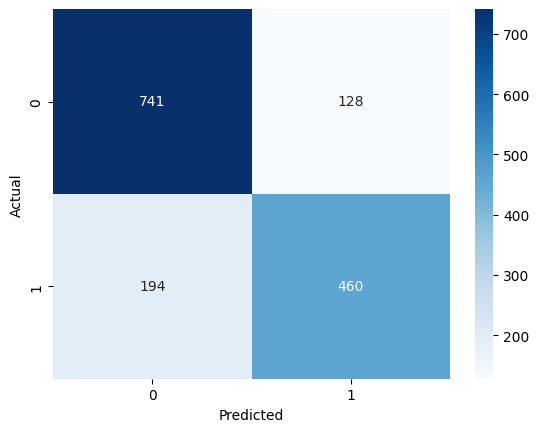

In [25]:
cm = confusion_matrix(y_test,pred_svm)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

The model correctly classified 741 non-disaster tweets and 460 disaster tweets. However, it misclassified 128 non-disaster tweets as disasters and missed 194 actual disaster tweets. Overall, the model performs reasonably well but can be improved in identifying disaster-related tweets.

In [26]:
import pickle

pickle.dump(lr,
            open('disaster_model.pkl','wb'))

pickle.dump(tfidf,
            open('tfidf.pkl','wb'))

In [27]:
import os 
print(os.listdir())

['.ipynb_checkpoints', '10th marksheet true copy.jpg', '12th marksheet true copy.jpg', '2025-05-06 Dell.mp3', '2025-05-06 Dell.mpdp', '2025-05-06 Dell.mpdp.ProjectData', '2025-05-07 Dell.mpdp', '2025-05-07 Dell.mpdp.ProjectData', 'aadhar true copy.jpg', 'Acrobat Reader.lnk', 'Adobe Express Photos.lnk', 'app.PY PROJECT 6.py', 'calculator project.py', 'Capstone project  ppt 11.pdf', 'Capstone project  WORD FILE.docx', 'Capstone project 1.ipynb', 'Capstone project ppt.pptx', 'dashboard.py', 'Data set 1 done.xlsx', 'Data set 2 done.xlsx', 'Data set 3 done.xlsx', 'degree true copy.jpg', 'desktop.ini', 'disaster folder', 'disaster_model.pkl', 'Dr._Sakshi_Jaiswal_Resume Done.pdf', 'feature_store.csv', 'Final merged data done (Recovered).xlsx', 'final photo.jpg', 'Final project 5 nexthikes.ipynb', 'final_telecom_data.csv', 'Google Meet.lnk', 'Guest list.xlsx', 'in.gov.abc-ABCID-573581580681.pdf', 'Jupyter notebook.lnk', 'Jupyter_Project_Presentation project 5.pptx', 'mall_customer_prediction.p